In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
from prophet import Prophet
from darts.models import VARIMA
from darts.models import ARIMA
from pmdarima.arima import auto_arima
from darts.models import Croston
from darts import TimeSeries

- darts에서 제공하는 ARIMA를 사용하자!

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_excel('../data/merged_data.xlsx')
df

,date,year,month,day,white,black,total
0,2023-08-01,2023,8,1,8,1,9
1,2023-08-02,2023,8,2,13,1,14
2,2023-08-03,2023,8,3,10,0,10
3,2023-08-04,2023,8,4,14,0,14
4,2023-08-05,2023,8,5,0,0,0
...,...,...,...,...,...,...,...
573,2025-02-24,2025,2,24,2,23,25
574,2025-02-25,2025,2,25,2,11,13
575,2025-02-26,2025,2,26,0,6,6
576,2025-02-27,2025,2,27,0,4,4


***

# EDA

In [7]:
def plot_separate_time_series(df, cols):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(3, 1, i)
        plt.plot(df['date'], df[col], label=col, color='tab:blue')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.title(f'{col} over time')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

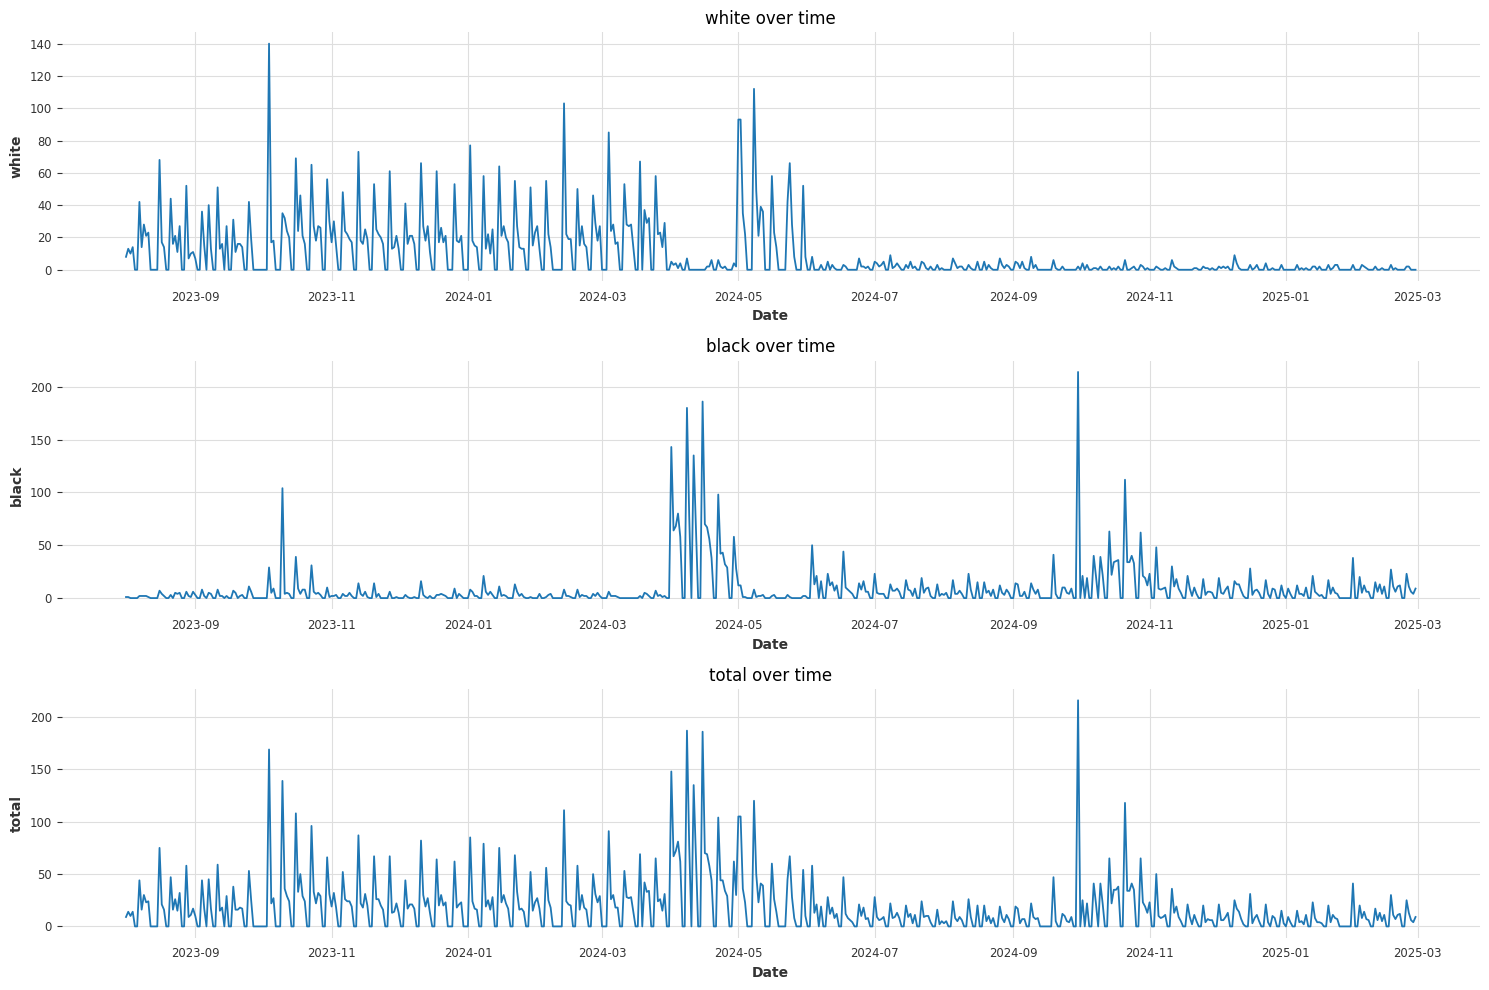

In [8]:
# 실행
plot_separate_time_series(df, ['white', 'black', 'total'])

***

# Auto_ARIMA

1. 맨 처음에 실행된 auto_arima에서 찾은 p,d,q를 설정하여 이후는 ARIMA를 실행함

In [11]:
def sliding_arima_forecast_darts(df, col, test_ratio=0.2, window_size=7):
    df = df.set_index('date')
    series = df[col].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    # (1) auto_arima로 p,d,q 탐색 (pmdarima 사용)
    model_init = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
    p, d, q = model_init.order
    print(f"[{col}] 고정된 ARIMA Order: ({p},{d},{q})")

    preds = []

    # Darts용 TimeSeries로 변환
    full_series = TimeSeries.from_series(series)
    train_ts = full_series[:split_idx]
    test_ts = full_series[split_idx:]

    # 슬라이딩 예측
    history = train_ts
    for i in range(0, len(test_ts), window_size):
        end_idx = min(i + window_size, len(test_ts))

        model = ARIMA(p=p, d=d, q=q)
        model.fit(history)

        forecast = model.predict(end_idx - i)
        preds.append(forecast)

        # history 업데이트
        history = history.append(test_ts[i:end_idx])

    # 전체 예측 연결
    forecast_series = preds[0]
    for f in preds[1:]:
        forecast_series = forecast_series.append(f)

    # 시각화
    plt.figure(figsize=(12, 5))
    test_ts.plot(label='Actual', color='black')
    forecast_series.plot(label='Forecast', color='red')
    plt.title(f'{col} - Sliding ARIMA Forecast (Darts)')
    plt.legend()
    plt.grid(True)
    plt.show()

[white] 고정된 ARIMA Order: (2,1,3)


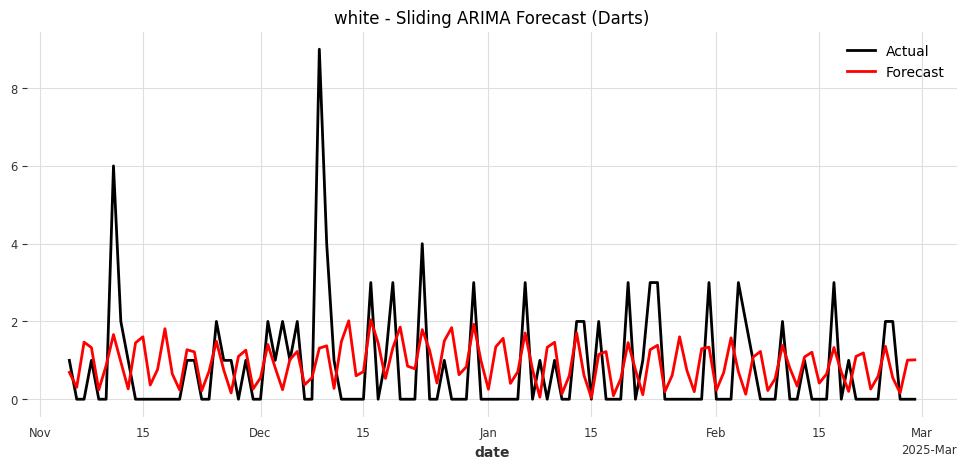

[black] 고정된 ARIMA Order: (2,1,1)


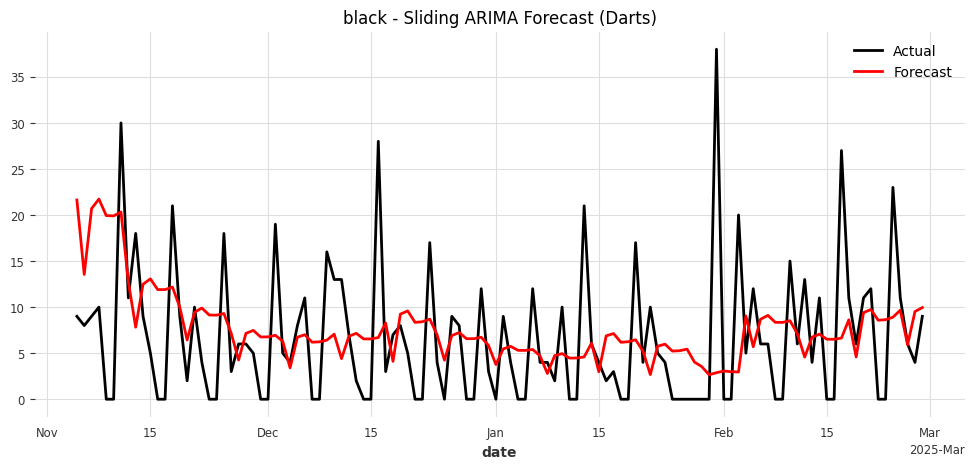

[total] 고정된 ARIMA Order: (5,1,5)


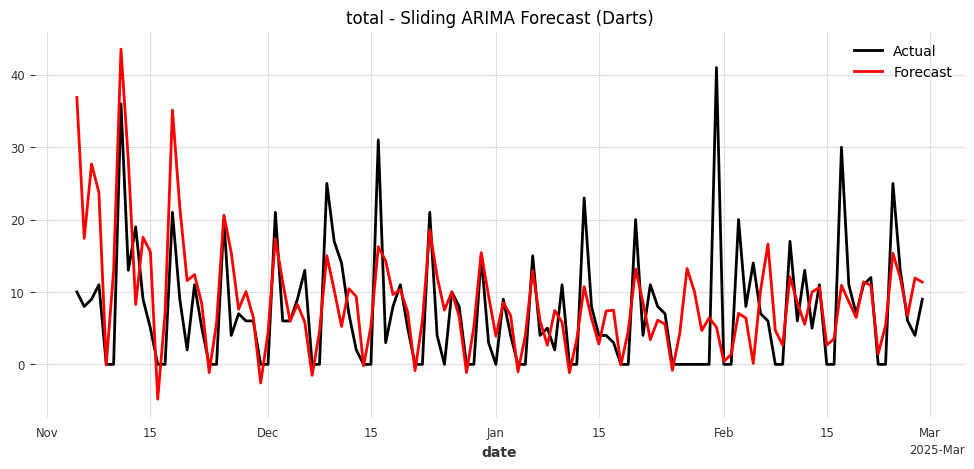

In [12]:
# white, black 컬럼에 대해 반복 실행
for col in ['white', 'black', 'total']:
    sliding_arima_forecast_darts(df, col)

2) 초기에 p,d,q를 설정하지 않고 7일(= window_size)마다 새롭게 auto_arima를 돌려서 가장 좋은 (p,d,q) 조합을 찾아서 예측에 사용

In [20]:
def sliding_arima_forecast_dynamic(df, col, test_ratio=0.2, window_size=3):
    df = df.set_index('date')
    series = df[col].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    preds = []

    # TimeSeries로 변환
    full_series = TimeSeries.from_series(series)
    train_ts = full_series[:split_idx]
    test_ts = full_series[split_idx:]

    # 슬라이딩 예측 시작
    history = train_ts

    for i in range(0, len(test_ts), window_size):
        end_idx = min(i + window_size, len(test_ts))

        # (1) 매 슬라이딩마다 p,d,q 재탐색
        # 수정된 코드
        history_pd = pd.Series(
            data=history.values().flatten(),
            index=history.time_index
        )
        
        model_init = auto_arima(history_pd, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
        p, d, q = model_init.order
        print(f"[{col}] {history.end_time().date()}까지 학습한 ARIMA Order: ({p},{d},{q})")

        # (2) darts ARIMA 모델 학습 및 예측
        model = ARIMA(p=p, d=d, q=q)
        model.fit(history)
        forecast = model.predict(end_idx - i)

        preds.append(forecast)

        # history 업데이트
        history = history.append(test_ts[i:end_idx])

    # 전체 예측 연결
    forecast_series = preds[0]
    for f in preds[1:]:
        forecast_series = forecast_series.append(f)

    # 시각화
    plt.figure(figsize=(12, 5))
    test_ts.plot(label='Actual', color='black')
    forecast_series.plot(label='Forecast', color='red')
    plt.title(f'{col} - Sliding ARIMA Forecast (Dynamic Order)')
    plt.legend()
    plt.grid(True)
    plt.show()

[white] 2024-11-04까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-07까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-11-10까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-13까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-11-16까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-19까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-11-22까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-25까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-11-28까지 학습한 ARIMA Order: (0,1,4)
[white] 2024-12-01까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-04까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-07까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-10까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-13까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-16까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-19까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-22까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-25까지 학습한 ARIMA Order: (2,1,3)
[white] 2024-12-28까지 학습한 ARIMA Order: (3,1,2)
[white] 2024-12-31까지 학습한 ARIMA Order: (2,1,3)
[white] 2025-01-03까지 학습한 ARIMA Order: (3,1,2)
[white] 2025-01-06까지 학습한 ARIMA Ord

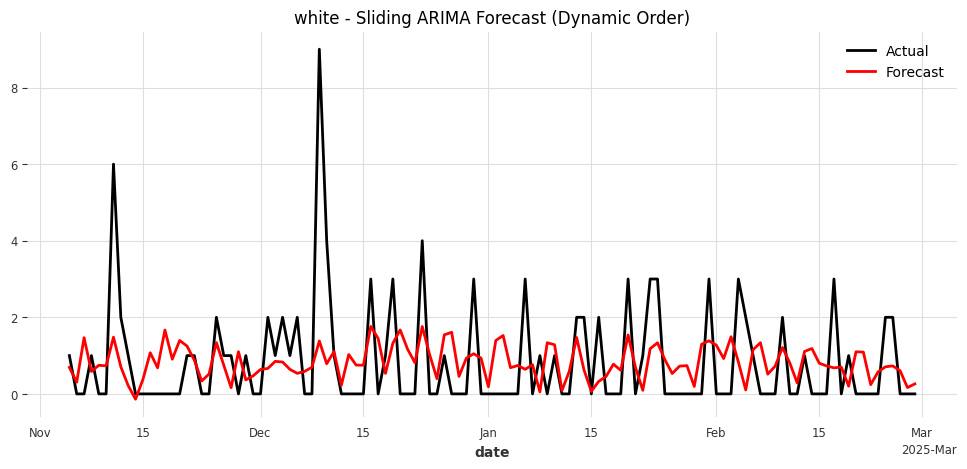

[black] 2024-11-04까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-07까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-10까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-13까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-16까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-19까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-22까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-25까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-11-28까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-01까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-04까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-07까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-10까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-13까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-16까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-19까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-22까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-25까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-28까지 학습한 ARIMA Order: (2,1,1)
[black] 2024-12-31까지 학습한 ARIMA Order: (2,1,1)
[black] 2025-01-03까지 학습한 ARIMA Order: (2,1,1)
[black] 2025-01-06까지 학습한 ARIMA Ord

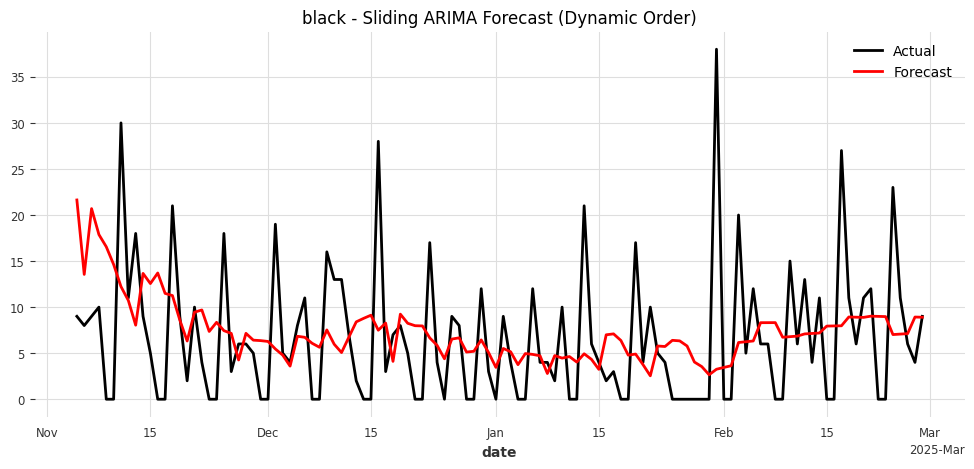

[total] 2024-11-04까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-07까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-10까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-13까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-16까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-19까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-22까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-25까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-11-28까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-01까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-04까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-07까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-10까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-13까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-16까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-19까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-22까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-25까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-28까지 학습한 ARIMA Order: (5,1,5)
[total] 2024-12-31까지 학습한 ARIMA Order: (5,1,5)
[total] 2025-01-03까지 학습한 ARIMA Order: (5,1,5)
[total] 2025-01-06까지 학습한 ARIMA Ord

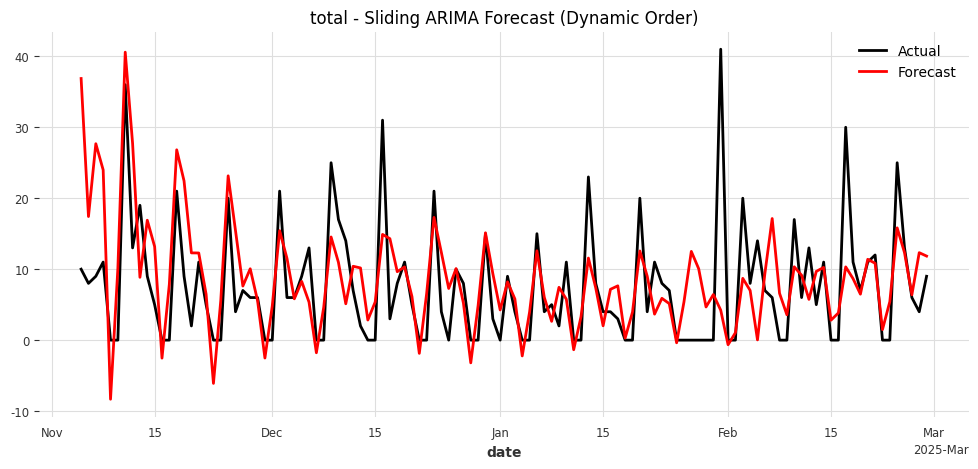

In [21]:
# 대상 컬럼별 반복 예측
target_cols = ['white', 'black', 'total']
for col in target_cols:
    sliding_arima_forecast_dynamic(df, col)

***

# Prophet

In [13]:
def prophet_forecast(df, col, test_ratio=0.2):
    series = df[['date', col]].copy()
    series.columns = ['ds', 'y']  # Prophet에 맞는 컬럼명

    # ✅ 결측치 0으로 채움 (간헐적 수요 반영)
    series['y'] = series['y'].fillna(0)

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    # Prophet 모델 학습
    model = Prophet()
    model.fit(train)

    # 미래 데이터프레임 생성
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    # 예측값 추출
    pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]

    # ✅ 음수 예측값을 0으로 수정 - relu
    pred['yhat'] = pred['yhat'].apply(lambda x: max(x, 0))

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], test['y'], label='Actual', color='black')
    plt.plot(pred.index, pred['yhat'], label='Forecast (Adjusted)', color='red')
    plt.title(f'{col} - Prophet Forecast (No Negative Values)')
    plt.legend()
    plt.grid(True)
    plt.show()

14:31:26 - cmdstanpy - INFO - Chain [1] start processing
14:31:27 - cmdstanpy - INFO - Chain [1] done processing


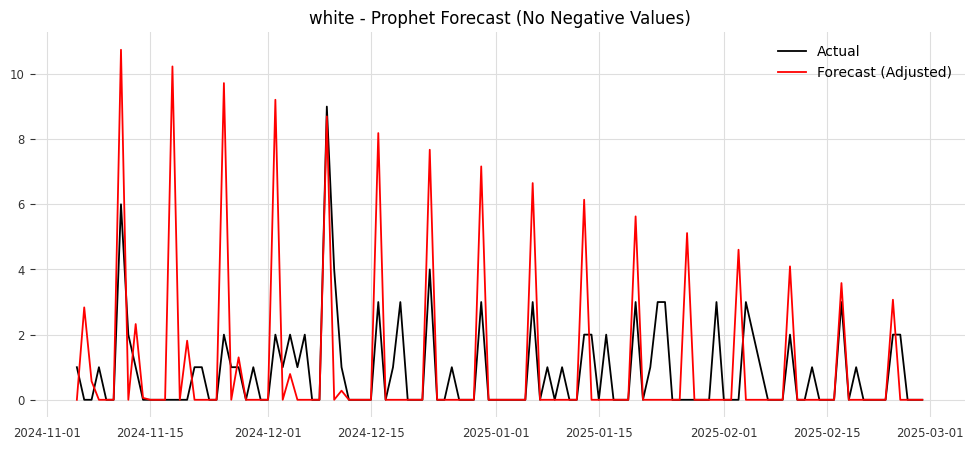

14:31:28 - cmdstanpy - INFO - Chain [1] start processing
14:31:28 - cmdstanpy - INFO - Chain [1] done processing


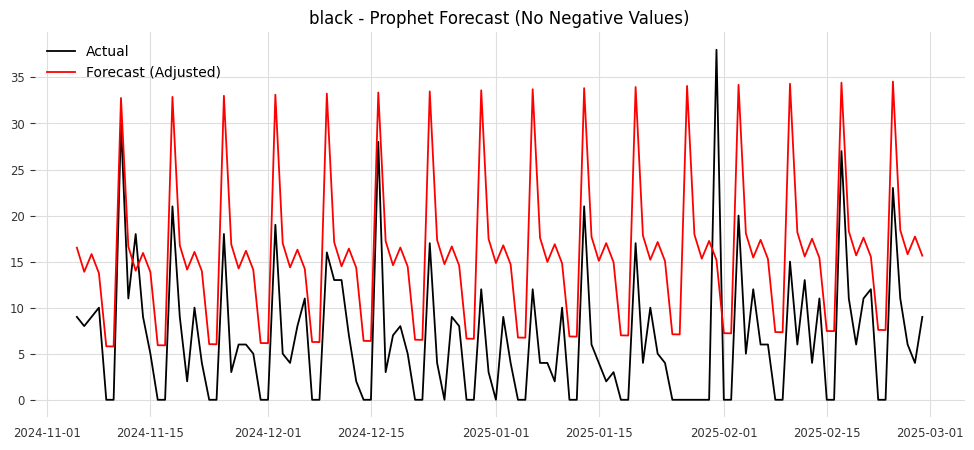

14:31:28 - cmdstanpy - INFO - Chain [1] start processing
14:31:28 - cmdstanpy - INFO - Chain [1] done processing


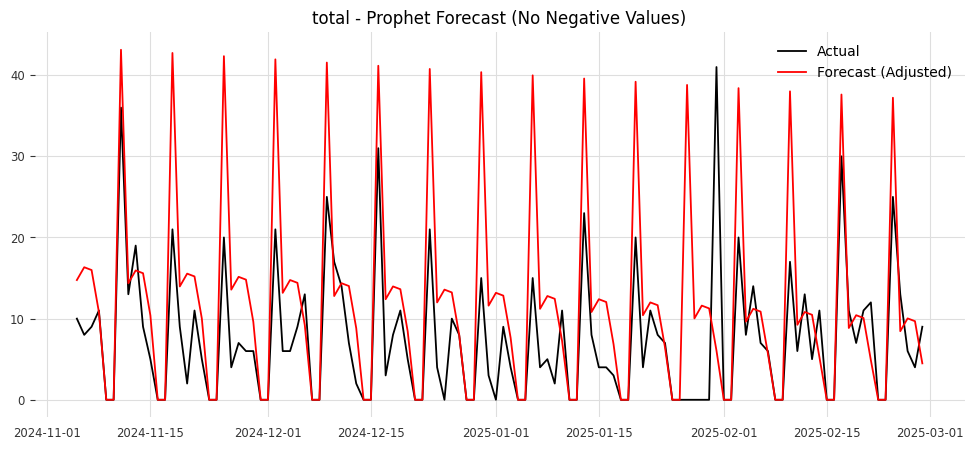

In [14]:
# 실행
target_cols = ['white', 'black', 'total']
for col in target_cols:
    prophet_forecast(df.copy(), col)

***

# VARIMA (다변량 시계열: 변수 간 상관성 반영)

In [19]:
def varima_forecast_sliding(df, cols, test_ratio=0.2, sliding_window=3):
    df = df[['date'] + cols].dropna().drop_duplicates(subset='date')
    df = df.set_index('date').asfreq('D')
    df = df.fillna(0)

    series = TimeSeries.from_dataframe(df)
    
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    history = train
    forecasts = []

    model = VARIMA(2,1,2) # 초기 모델 fit
    model.fit(history)

    for i in range(0, len(test), sliding_window):
        n_predict = min(sliding_window, len(test) - i)

        forecast = model.predict(n_predict)
        forecasts.append(forecast)

        # update: 예측 끝난 부분까지 실제 test data를 추가
        history = history.append(test[i:i+n_predict])

        # 모델 재학습 (원래 VARIMA는 incremental learning이 어려워서 다시 fit)
        model = VARIMA(2,1,2)
        model.fit(history)

    # 모든 작은 forecasts를 이어붙임
    forecast_all = forecasts[0]
    for f in forecasts[1:]:
        forecast_all = forecast_all.append(f)

    # 시각화
    for col in cols:
        plt.figure(figsize=(12, 5))
        test[col].plot(label='Actual', color='black')
        forecast_all[col].plot(label='Sliding VARIMA Forecast', color='red')
        plt.title(f'{col} - VARIMA Sliding Forecast')
        plt.legend()
        plt.grid(True)
        plt.show()

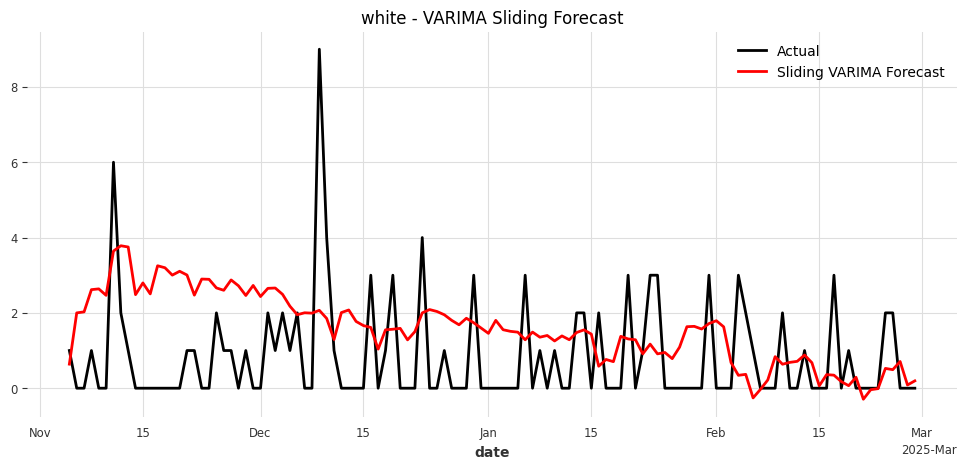

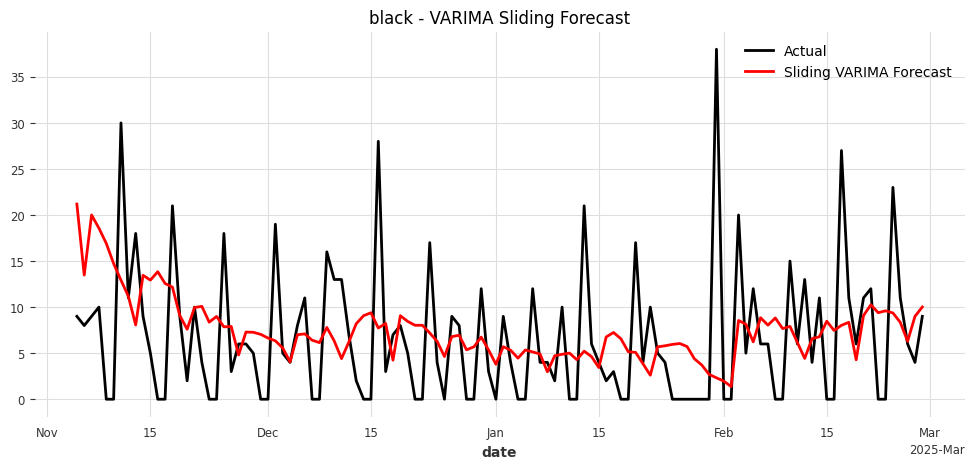

In [20]:
varima_forecast_sliding(df, ['white', 'black'])

***

# 캘린더 특성 추가하기: holidayskr 라이브러리
> https://yoonminlee.com/python-holidayskr-korean-holiday-check-guide

In [1]:
from holidayskr import is_holiday

if is_holiday('2024-05-05'):
    print("2024년 5월 5일은 공휴일입니다.")
else:
    print("2024년 5월 5일은 공휴일이 아닙니다.")

2024년 5월 5일은 공휴일입니다.


In [2]:
from holidayskr import today_is_holiday

if today_is_holiday():
    print("오늘은 공휴일입니다.")
else:
    print("오늘은 공휴일이 아닙니다.")

오늘은 공휴일입니다.


In [4]:
from holidayskr import year_holidays

holidays = year_holidays('2025')
for holiday_date, holiday_name in holidays:
    print(f"{holiday_date.strftime('%Y년 %m월 %d일')}은 {holiday_name}입니다.")

2025년 01월 01일은 신정입니다.
2025년 01월 27일은 대체 공휴일(설날)입니다.
2025년 01월 28일은 설날 전날입니다.
2025년 01월 29일은 설날입니다.
2025년 01월 30일은 설날 다음날입니다.
2025년 03월 01일은 3·1절입니다.
2025년 03월 03일은 대체 공휴일(3·1절)입니다.
2025년 05월 01일은 근로자의 날입니다.
2025년 05월 05일은 어린이날입니다.
2025년 05월 05일은 석가탄신일입니다.
2025년 05월 06일은 대체 공휴일(어린이날, 석가탄신일 중복 공휴일)입니다.
2025년 06월 06일은 현충일입니다.
2025년 08월 15일은 광복절입니다.
2025년 10월 03일은 개천절입니다.
2025년 10월 05일은 추석 전날입니다.
2025년 10월 06일은 추석입니다.
2025년 10월 07일은 추석 다음날입니다.
2025년 10월 08일은 대체 공휴일(추석)입니다.
2025년 10월 09일은 한글날입니다.
2025년 12월 25일은 크리스마스입니다.


***

In [16]:
from holidayskr import year_holidays

def get_korean_holidays(start_year, end_year):
    holidays = []
    for year in range(start_year, end_year + 1):
        for date, name in year_holidays(str(year)):
            holidays.append({'ds': pd.to_datetime(date), 'holiday': name})
    return pd.DataFrame(holidays)

In [19]:
def prophet_forecast(df, col, test_ratio=0.2):
    series = df[['date', col]].copy()
    series.columns = ['ds', 'y']

    series['y'] = series['y'].fillna(0)

    split_idx = int(len(series) * (1 - test_ratio))
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    # ✅ 공휴일 데이터 가져오기
    start_year = series['ds'].min().year
    end_year = series['ds'].max().year
    holiday_df = get_korean_holidays(start_year, end_year)

    # ✅ Prophet에 공휴일 반영
    model = Prophet(holidays=holiday_df)
    model.fit(train)

    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]
    pred['yhat'] = pred['yhat'].apply(lambda x: max(x, 0))

    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], test['y'], label='Actual', color='black')
    plt.plot(pred.index, pred['yhat'], label='Forecast (w/ Holidays)', color='red')
    plt.title(f'{col} - Prophet Forecast (with Korean Holidays)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Prophet 구성 요소(트렌드, 계절성, 공휴일 효과 등) 시각화
    model.plot_components(forecast)
    plt.tight_layout()
    plt.show()

- 공휴일의 효과 크기 시각화
  - holidays → 날짜별로 공휴일이 수요에 얼마나 영향을 미쳤는지 (상승/감소)
  - weekly → 요일별 수요 패턴
  - yearly → 연간 계절성
  - trend → 수요 추세

holidays 그래프를 살펴보자.

> y축 (holidays): 공휴일로 인한 수요의 변화량
> - 양수 값: 해당 공휴일이 수요를 증가시켰음을 의미
> - 음수 값: 해당 공휴일이 수요를 감소시켰음을 의미
> - 값이 클수록 영향력이 크며, y축의 단위는 예측 대상 수요량의 단위와 동일
>
🔎 왜 어떤 공휴일은 수요가 감소하고, 어떤 날은 증가할까?
- 이는 데이터 자체에 반영된 패턴에 기반한 모델의 판단
    - 어린이날, 추석 전날 등 → 선물 수요 등으로 증가
    - 설날 연휴, 크리스마스 → 유통 중단/휴무로 인해 감소
    - 일부 날짜는 영향이 없음 (값 = 0): 수요 변화가 감지되지 않아서 Prophet이 해당 공휴일의 효과를 무시함

14:59:51 - cmdstanpy - INFO - Chain [1] start processing
14:59:51 - cmdstanpy - INFO - Chain [1] done processing


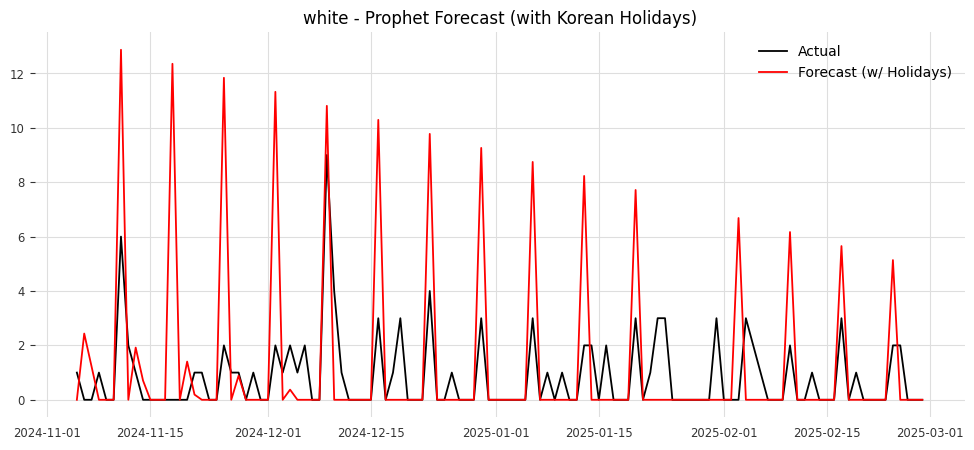

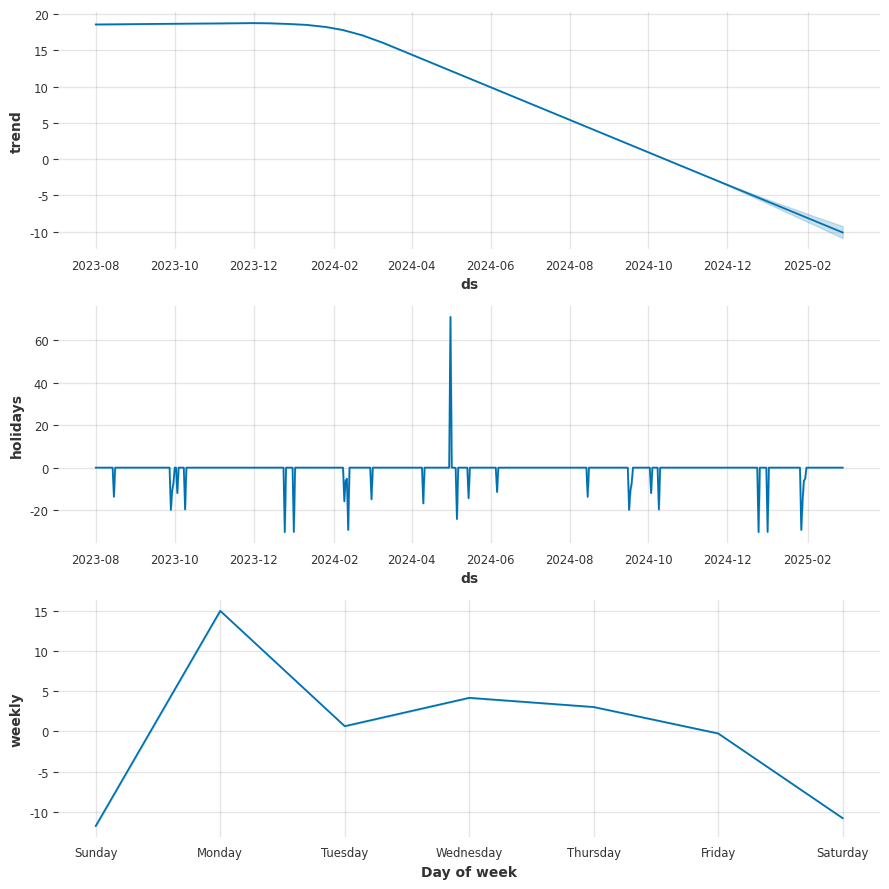

14:59:52 - cmdstanpy - INFO - Chain [1] start processing
14:59:52 - cmdstanpy - INFO - Chain [1] done processing


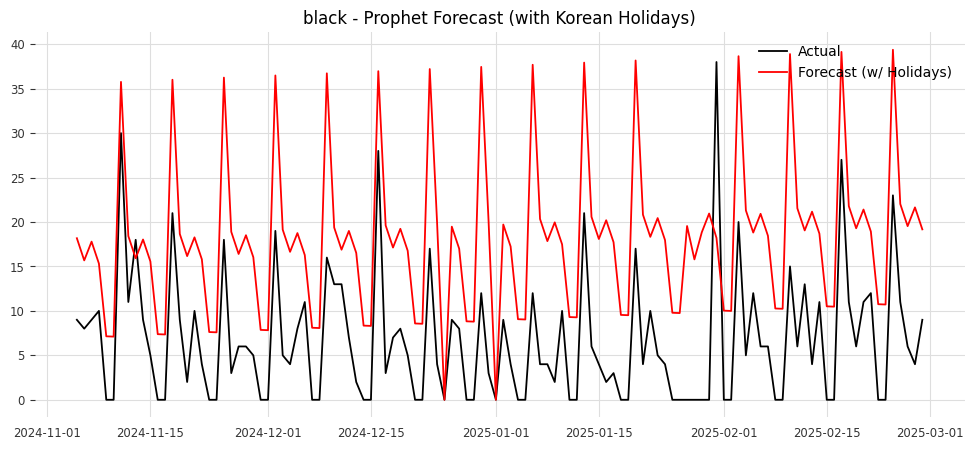

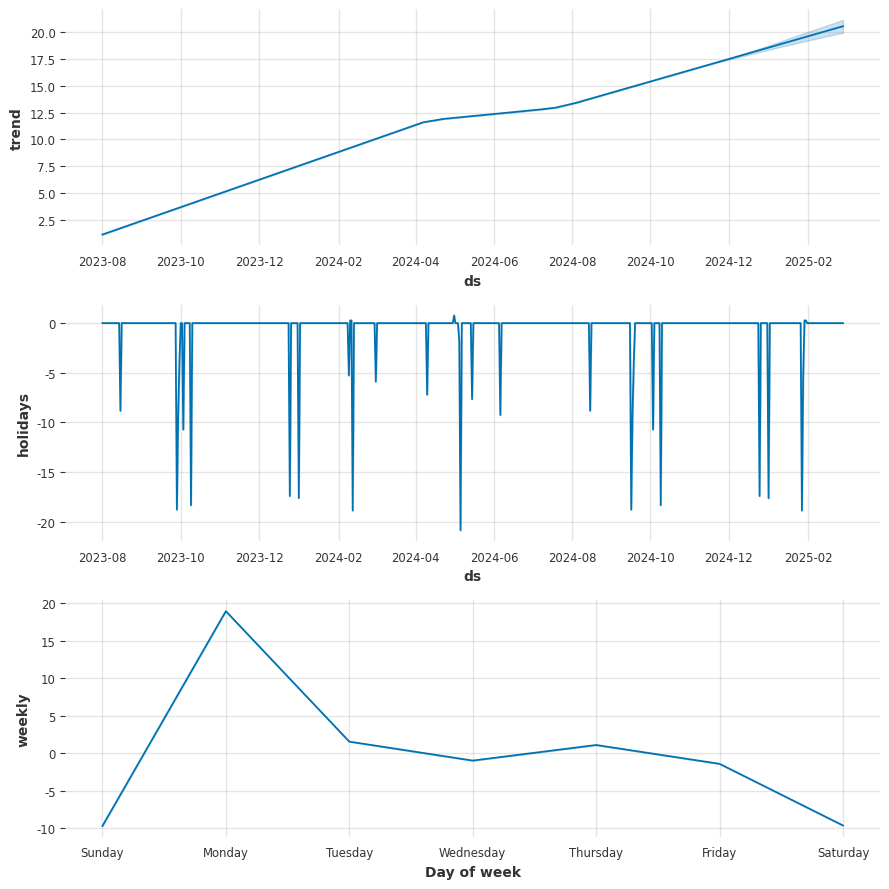

14:59:53 - cmdstanpy - INFO - Chain [1] start processing
14:59:53 - cmdstanpy - INFO - Chain [1] done processing


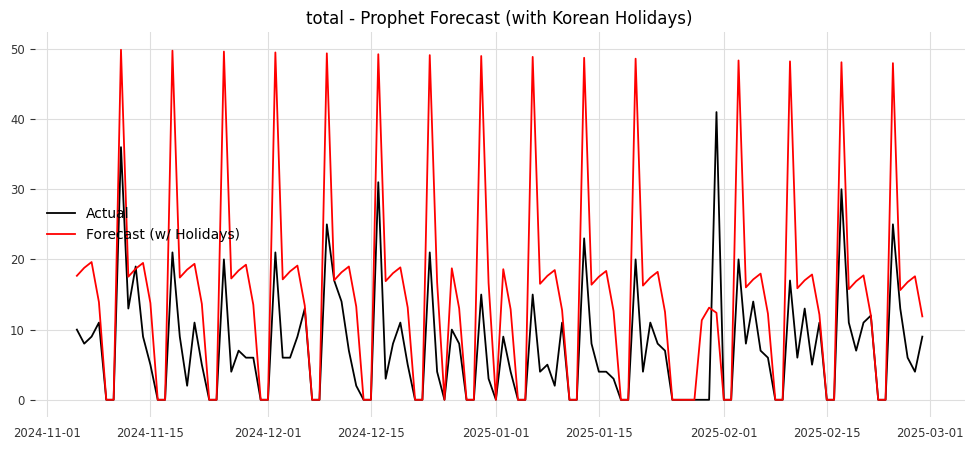

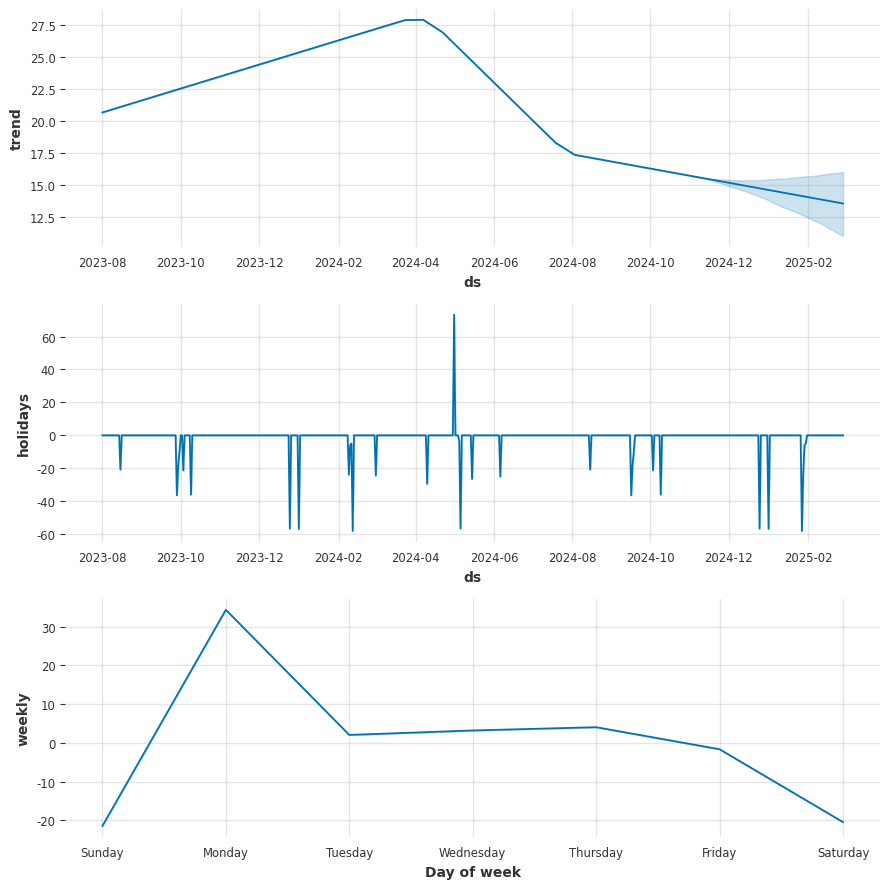

In [20]:
# 실행
target_cols = ['white', 'black', 'total']
for col in target_cols:
    prophet_forecast(df.copy(), col)

***

# 외부 데이터 테스트

In [14]:
data = pd.read_csv('../data/walmart_cleaned.csv')

In [16]:
data = data.drop('Unnamed: 0', axis=1)
data.head(3)

,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315


In [26]:
def prophet_forecast(df, col, test_ratio=0.2):
    series = df[['Date', col]].copy()
    series.columns = ['ds', 'y']  # Prophet에 맞는 컬럼명

    # ✅ 결측치 0으로 채움 (간헐적 수요 반영)
    series['y'] = series['y'].fillna(0)

    # 주 단위 정렬
    series = series.sort_values('ds')
    series = series.set_index('ds').resample('W').sum().reset_index()

    # Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    # Prophet 학습
    model = Prophet()
    model.fit(train)

    # ✅ 주 단위 future 생성
    future = model.make_future_dataframe(periods=len(test), freq='W')
    forecast = model.predict(future)

    # 예측값 추출
    pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]
    pred['yhat'] = pred['yhat'].apply(lambda x: max(x, 0))

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], test['y'], label='Actual', color='black')
    plt.plot(pred.index, pred['yhat'], label='Forecast (Adjusted)', color='red')
    plt.title(f'{col} - Prophet Forecast (Weekly)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
data['Date'] = pd.to_datetime(data['Date'])

16:10:28 - cmdstanpy - INFO - Chain [1] start processing
16:10:28 - cmdstanpy - INFO - Chain [1] done processing


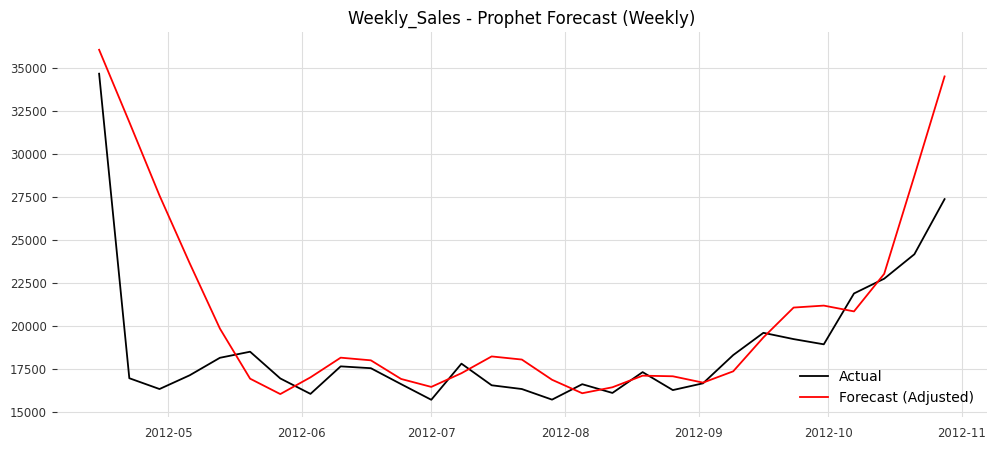

In [28]:
# Store=1, Dept=1 데이터만 추출
sub_df = data[(data['Store'] == 1) & (data['Dept'] == 1)].sort_values('Date')

# 함수 적용
prophet_forecast(sub_df, col='Weekly_Sales')

In [29]:
data2 = pd.read_csv('../data/retail_store_inventory.csv')

In [30]:
data2.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer


In [ ]:
data2['Date'] = pd.to_datetime(data2['Date'])

# 2. 특정 store/item 선택 (예: store 1, item 1)
df = data2[(data2['store'] == 1) & (data2['item'] == 1)].copy()

# 3. Prophet 입력 형식 맞추기
df = df[['Date', 'sales']].rename(columns={'Date': 'ds', 'sales': 'y'})
df['y'] = df['y'].fillna(0)  # 결측치 채우기

# 4. Train/Test 나누기
test_ratio = 0.2
split_idx = int(len(df) * (1 - test_ratio))
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# 5. Prophet 모델 학습
model = Prophet()
model.fit(train)

# 6. 미래 데이터프레임 생성 및 예측
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# 7. 예측값 추출 및 음수 제거
pred = forecast[['ds', 'yhat']].set_index('ds').loc[test['ds']]
pred['yhat'] = pred['yhat'].apply(lambda x: max(x, 0))  # 음수 제거

# 8. 시각화
plt.figure(figsize=(12, 5))
plt.plot(test['ds'], test['y'], label='Actual', color='black')
plt.plot(pred.index, pred['yhat'], label='Forecast', color='red')
plt.title('Prophet Forecast: Store 1 - Item 1')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend()
plt.show()